In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn 
import seaborn as sns

In [2]:
cars_file = 'https://gist.githubusercontent.com/noamross/e5d3e859aa0c794be10b/raw/b999fb4425b54c63cab088c0ce2c0d6ce961a563/cars.csv'
cars = pd.read_csv(cars_file)
cars.head()

,Unnamed: 0,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


<Axes: xlabel='wt', ylabel='mpg'>

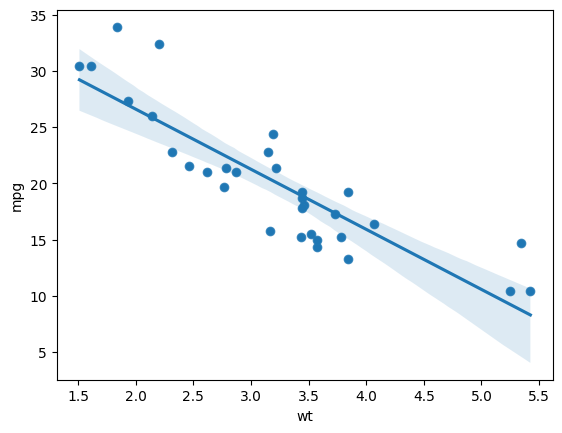

In [5]:
sns.scatterplot(x='wt', y='mpg', data=cars)
sns.regplot(x='wt', y='mpg', data=cars)

# we can see here that the mileage decreases as the weight increases
# we will replicate the regression line using neural networks

In [10]:
# convert data to tensor
X_list = cars.wt.values

X_np = np.array(X_list, dtype=np.float32).reshape(-1,1)
y_list = cars.mpg.values.tolist()
y_np = np.array(y_list, dtype=np.float32).reshape(-1,1)

# this is how to convert numpy arrays to tensors
X = torch.from_numpy(X_np)
# this is how to convert lists to tensors
y = torch.tensor(y_list)

In [11]:
print("X tensor")
print(X)

X tensor
tensor([[2.6200],
        [2.8750],
        [2.3200],
        [3.2150],
        [3.4400],
        [3.4600],
        [3.5700],
        [3.1900],
        [3.1500],
        [3.4400],
        [3.4400],
        [4.0700],
        [3.7300],
        [3.7800],
        [5.2500],
        [5.4240],
        [5.3450],
        [2.2000],
        [1.6150],
        [1.8350],
        [2.4650],
        [3.5200],
        [3.4350],
        [3.8400],
        [3.8450],
        [1.9350],
        [2.1400],
        [1.5130],
        [3.1700],
        [2.7700],
        [3.5700],
        [2.7800]])


In [12]:
print("y tensor")
print(y)

y tensor
tensor([21.0000, 21.0000, 22.8000, 21.4000, 18.7000, 18.1000, 14.3000, 24.4000,
        22.8000, 19.2000, 17.8000, 16.4000, 17.3000, 15.2000, 10.4000, 10.4000,
        14.7000, 32.4000, 30.4000, 33.9000, 21.5000, 15.5000, 15.2000, 13.3000,
        19.2000, 27.3000, 26.0000, 30.4000, 15.8000, 19.7000, 15.0000, 21.4000])


In [21]:
# create the weights and biases
w = torch.rand(1, requires_grad=True, dtype=torch.float64)
b = torch.rand(1, requires_grad=True, dtype=torch.float64)
print(w)
print(b)

tensor([0.0990], dtype=torch.float64, requires_grad=True)
tensor([0.3616], dtype=torch.float64, requires_grad=True)


In [23]:
# define the number of epochs
# epochs is the number of times the model will see the data
# An epoch of 1000 means that the neural network will go
# through the entire training dataset 1000 times during the training process.
n_epochs = 1000 


# Learning Rate in Neural Networks

The learning rate is a crucial hyperparameter in the training of neural
networks. It determines the step size at each iteration while moving toward a
minimum of the loss function.

- <b>Gradient Descent</b>: During training, the model uses an optimization algorithm like gradient descent to minimize the loss function. This involves updating the model's parameters (weights and biases) in the direction that reduces the error.

- <b>Step Size</b>: The learning rate controls how big these steps are. A higher learning rate means bigger steps, while a lower learning rate means smaller steps.

- <b>Balance</b>:

    `Too High`: If the learning rate is too high, the model might take large steps and overshoot the minimum. This can lead to instability and poor convergence.

    `Too Low`: If the learning rate is too low, the model will take very small steps, which can result in a very slow training process. It might also get stuck in a local minimum and never reach the best possible solution.

- <b>Adjustment</b>: Learning rate is adjusted during training. Techniques like
  learning rate schedules or adaptive learning rates (used in optimizers like
  Adam or RMSprop) help improve performance by changing the learning rate
  dynamically.


# Gradient Descent

<img src="figures/gradient_descent_gif.gif" alt="Alt text" width="500"
height="300">

# Step Size

<img src="figures/step_size.gif" alt="Alt text" width="500"
height="300">

A step size of 0.5 with gradient descent will reach the minimum in one step.

Any learning rate lower than 0.5 leads to slower convergence.

Any learning rate higher than 0.5 (but less than 1) leads to oscillations around the minimum till it finally lands at the minimum.

A learning rate α=1 for this function. The iterations just keep oscillating.

A learning rate greater than 1 leads to the iterations moving away from the minimum.

In [24]:
# define the learning rate  
learning_rate = 0.01

In [ ]:
# 

for epoch in range(num_epochs):
  for i in range(len(X)):
    # x, y = torch.tensor(X_list[i]), torch.tensor(y_list[i])
    # forward pass
    y_predict = X[i] * w + b
    # calculate loss
    loss_tensor = torch.pow(y_predict - y[i], 2)
    # backward pass
    loss_tensor.backward()
    # extract losses
    loss_value = loss_tensor.data[0]
    # update weights and biases
    with torch.no_grad():
      w -= w.grad * learning_rate
      b -= b.grad * learning_rate
      w.grad.zero_()
      b.grad.zero_()
  print(loss_value)